<a href="https://colab.research.google.com/github/dariakadina/satprak/blob/main/_EDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Исследование об успеваемости студентов на экзаменах.

## Описание проекта

В этом проекте проводится разведочный анализ данных об успеваемости студентов.  
Датасет содержит информацию о характеристиках студентов и их результатах по трем экзаменам: математике, чтению и письму.

На данном этапе основная задача — провести EDA, изучить структуру данных, выявить возможные закономерности и сформулировать будущую задачу машинного обучения.

**Датасет:** Students Performance in Exams  
**Источник:** Kaggle  
**Тип будущей ML-задачи:** регрессия  
**Будущая целевая переменная:** `average_score` — средний балл по математике, чтению и письму.

## 1. Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

## 2. Загрузка данных


In [3]:

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Описание датасета

В датасете каждая строка соответствует одному студенту.

Признаки:

- `gender` — пол студента;
- `race/ethnicity` — группа студента;
- `parental level of education` — уровень образования родителей;
- `lunch` — тип питания;
- `test preparation course` — прохождение подготовительного курса;
- `math score` — балл по математике;
- `reading score` — балл по чтению;
- `writing score` — балл по письму.

Цель EDA — понять, как распределены экзаменационные баллы и какие характеристики студентов могут быть связаны с более высокой или более низкой успеваемостью.

## 4. Первичный обзор данных

На этом этапе посмотрим размер датасета, типы переменных и базовую статистику по числовым признакам.

In [4]:
print("Размер датасета:", df.shape)
df.info()

Размер датасета: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.describe(include="object")

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


### Предварительный вывод

Первичный обзор позволяет понять, какие переменные являются числовыми, а какие категориальными.  
Также можно оценить диапазон экзаменационных баллов и количество уникальных категорий в текстовых признаках.

## 5. Проверка пропусков и дубликатов

Проверим, есть ли в данных пропущенные значения и повторяющиеся строки.

In [7]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [8]:
duplicates = df.duplicated().sum()
print("Количество дубликатов:", duplicates)

Количество дубликатов: 0


In [9]:
# Если дубликаты есть мы их удаляем
df = df.drop_duplicates()
print("Размер датасета после удаления дубликатов:", df.shape)

Размер датасета после удаления дубликатов: (1000, 8)


### Вывод

Проверка пропусков и дубликатов нужна для оценки качества данных.  
Если пропусков нет, можно переходить к дальнейшему анализу без сложной очистки данных.

## 6. Создание переменной `average_score`

Для дальнейшего анализа создадим показатель среднего экзаменационного балла студента:

`average_score = (math score + reading score + writing score) / 3`

Эта переменная будет использоваться как основной показатель общей успеваемости.

In [10]:
df["average_score"] = (
    df["math score"] + df["reading score"] + df["writing score"]
) / 3

df[["math score", "reading score", "writing score", "average_score"]].head()

,math score,reading score,writing score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


In [11]:
df["average_score"].describe()

,average_score
count,1000.000000
mean,67.770667
std,14.257326
min,9.000000
25%,58.333333
50%,68.333333
75%,77.666667
max,100.000000


## 7. Анализ распределения экзаменационных баллов

Посмотрим распределения баллов по математике, чтению, письму и среднего балла.

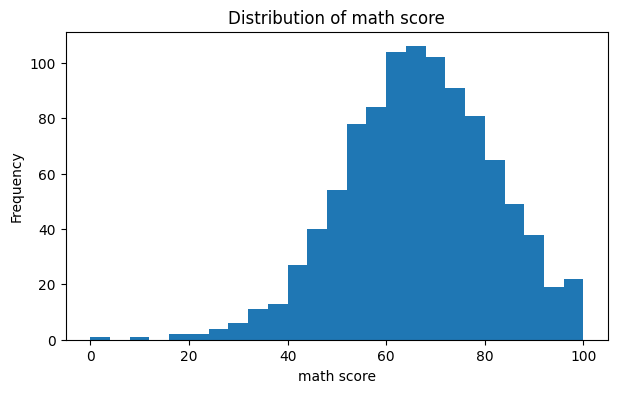

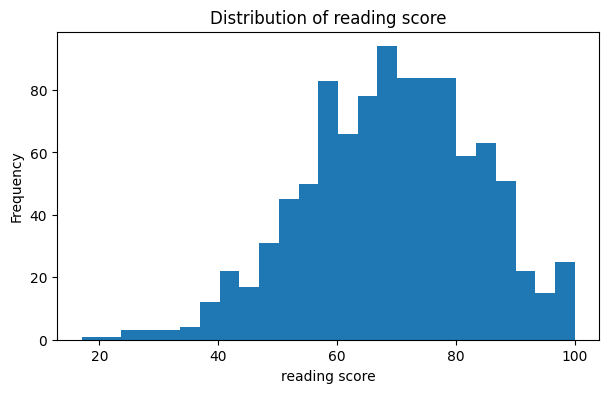

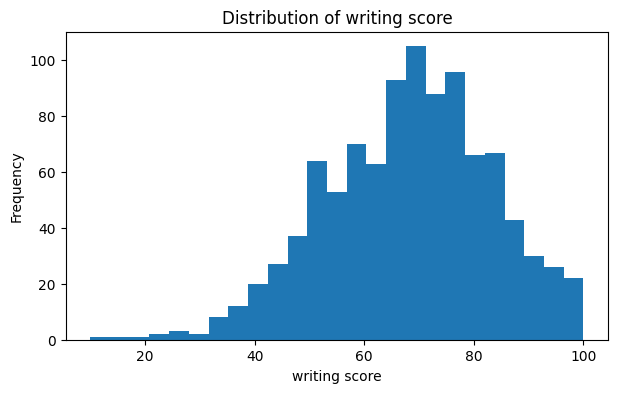

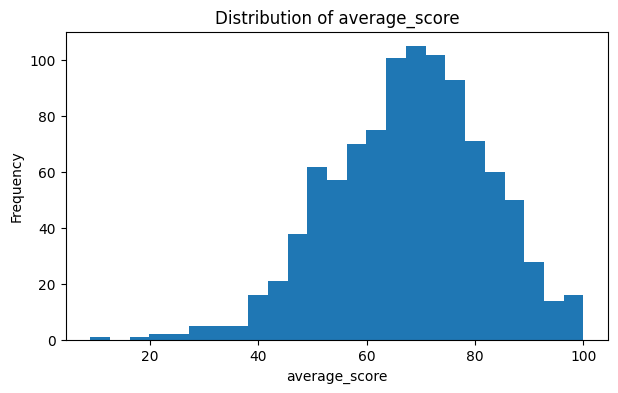

In [12]:
score_columns = ["math score", "reading score", "writing score", "average_score"]

for col in score_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=25)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Вывод по распределению экзаменационных баллов

Гистограммы показывают, как распределены результаты студентов по каждому экзамену и по среднему баллу.

Выводы:

1. **Большинство наблюдений сосредоточено в средней и верхней части шкалы**, то есть основная масса студентов получает не крайне низкие, а средние или достаточно высокие баллы.
2. **Распределения баллов по чтению и письму выглядят похожими**, что согласуется с тем, что эти экзамены проверяют близкие навыки — работу с текстом, понимание и письменное выражение мысли.
3. **Распределение баллов по математике может отличаться от reading и writing**, так как математика проверяет другой тип навыков. Поэтому далее важно смотреть не только общий средний балл, но и отдельные предметы.
4. **Переменная `average_score` имеет более сглаженное распределение**, потому что она является средним значением трех экзаменационных результатов. За счет усреднения отдельные резкие отклонения частично сглаживаются.
5. **Явных критических проблем в распределениях не видно**: значения находятся в ожидаемом диапазоне от 0 до 100, а значит данные выглядят логичными для экзаменационных баллов.



## 8. Сравнение среднего балла по группам

Теперь посмотрим, как средний экзаменационный балл отличается между группами студентов.


 gender
gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64


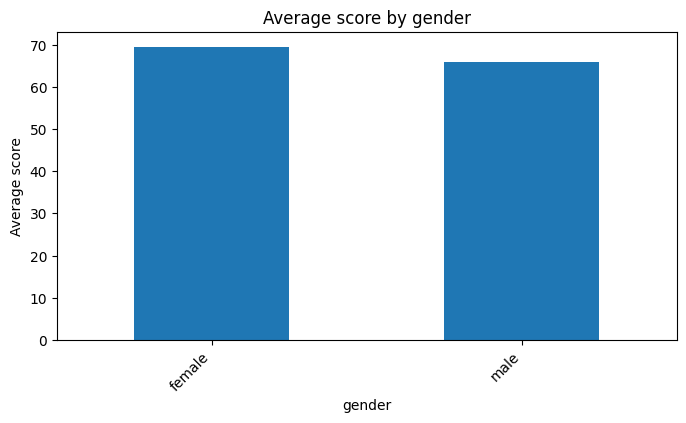


 race/ethnicity
race/ethnicity
group E    72.752381
group D    69.179389
group C    67.131661
group B    65.468421
group A    62.992509
Name: average_score, dtype: float64


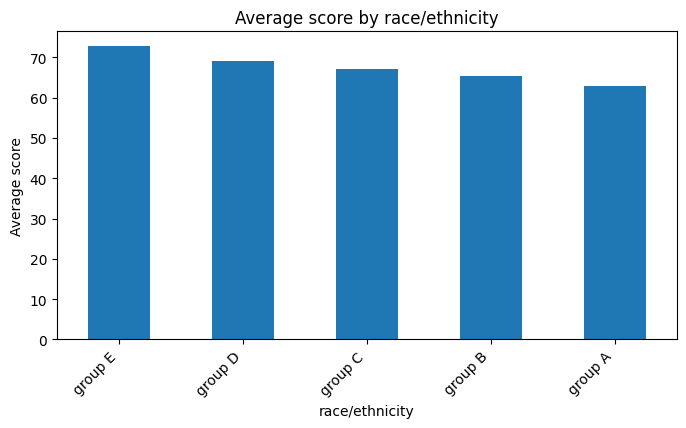


 parental level of education
parental level of education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64


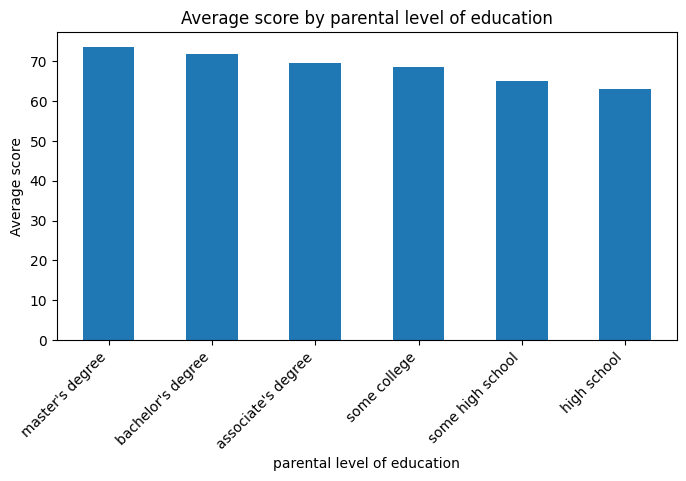


 lunch
lunch
standard        70.837209
free/reduced    62.199061
Name: average_score, dtype: float64


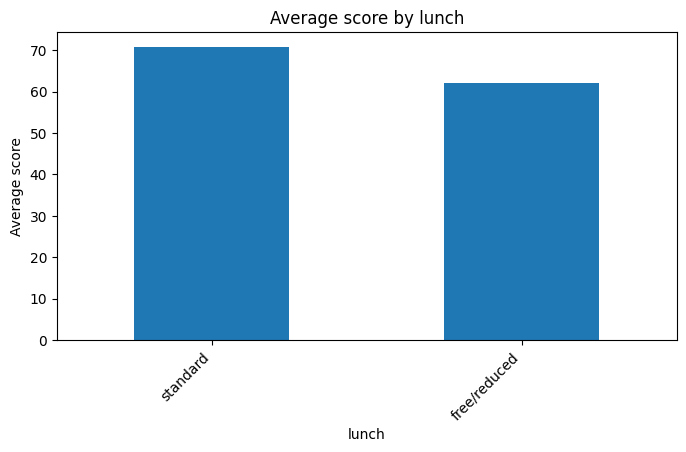


 test preparation course
test preparation course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64


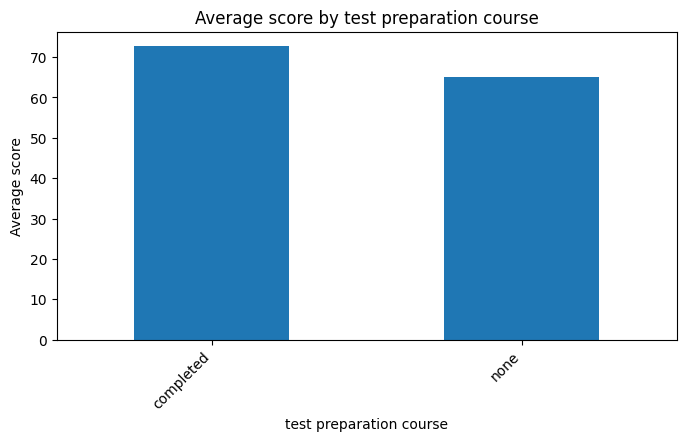

In [13]:
categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for col in categorical_columns:
    group_stats = (
        df.groupby(col)["average_score"]
        .mean()
        .sort_values(ascending=False)
    )

    print("\n", col)
    print(group_stats)

    plt.figure(figsize=(8, 4))
    group_stats.plot(kind="bar")
    plt.title(f"Average score by {col}")
    plt.xlabel(col)
    plt.ylabel("Average score")
    plt.xticks(rotation=45, ha="right")
    plt.show()

### Вывод

Сравнение средних значений помогает понять, какие категориальные признаки потенциально связаны с успеваемостью.  
Например, можно посмотреть, отличаются ли результаты у студентов, прошедших подготовительный курс, и у студентов, которые его не проходили.

## 9. Boxplot: разброс среднего балла по группам

 Средний уровень баллов, разброс значений внутри каждой группы.

<Figure size 800x400 with 0 Axes>

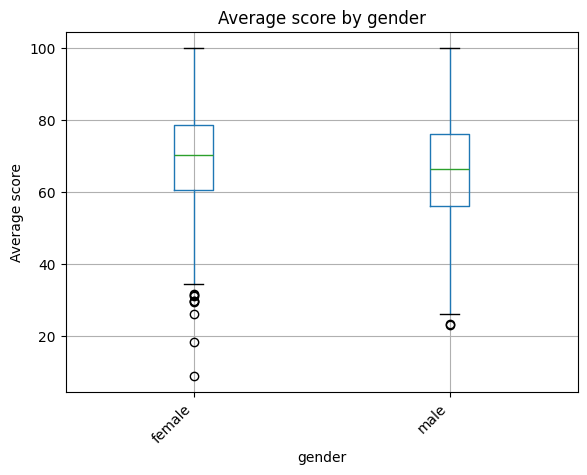

<Figure size 800x400 with 0 Axes>

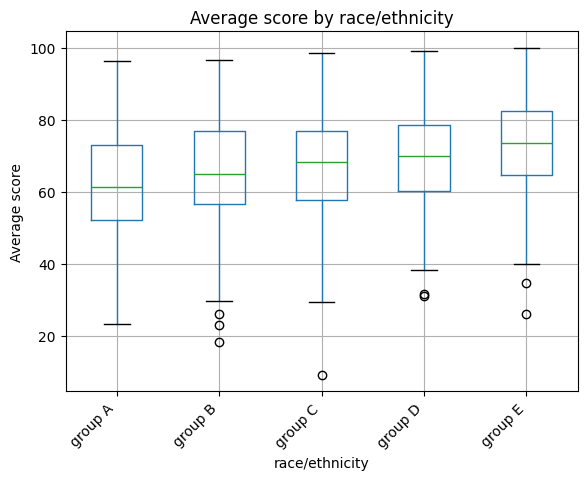

<Figure size 800x400 with 0 Axes>

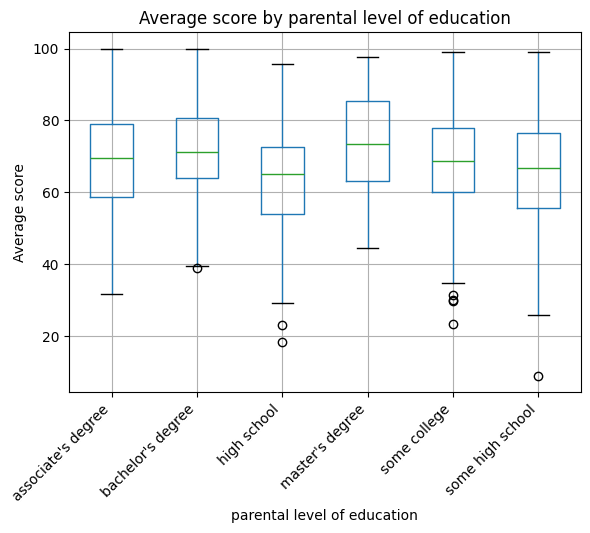

<Figure size 800x400 with 0 Axes>

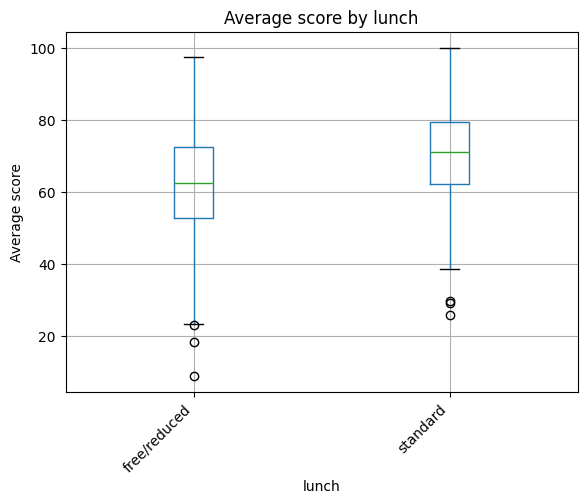

<Figure size 800x400 with 0 Axes>

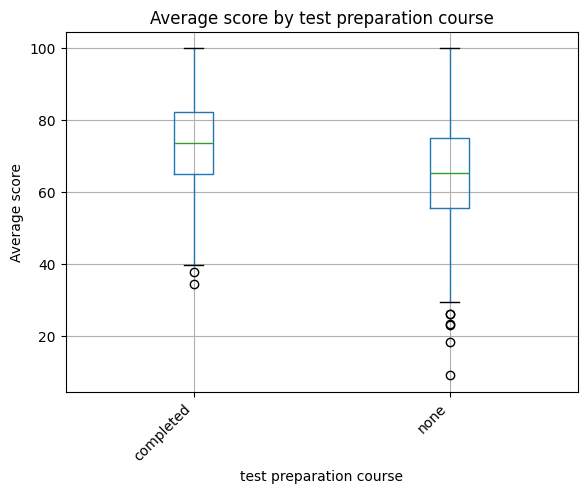

In [14]:
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    df.boxplot(column="average_score", by=col)
    plt.title(f"Average score by {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel("Average score")
    plt.xticks(rotation=45, ha="right")
    plt.show()

### Вывод по boxplot

Boxplot показывает, как распределяется средний балл внутри каждой группы, поэтому он дополняет сравнение простых средних значений.

Выводы из графика:

1. **Подготовительный курс** визуально связан с более высокими результатами: у студентов, прошедших курс, медианный `average_score` выше, чем у тех, кто его не проходил.
2. **Тип питания** также выглядит важным фактором: группа со `standard lunch` имеет более высокую медиану и в целом более высокие значения среднего балла, чем группа с `free/reduced lunch`.
3. **Уровень образования родителей** может быть связан с успеваемостью, но различия между группами не выглядят одинаково сильными для всех категорий. Это означает, что фактор может быть полезен для анализа, но его влияние нужно проверять аккуратно.
4. **Разброс баллов внутри групп достаточно заметный**, поэтому нельзя делать вывод, что один фактор полностью определяет успеваемость. Например, даже внутри одной категории есть студенты как с высокими, так и с низкими результатами.
5. **Выбросы и крайние значения** показывают, что в отдельных группах встречаются студенты с существенно более низкими или более высокими баллами.





## 10. Корреляционный анализ

Посмотрим, насколько связаны между собой баллы по разным экзаменам.

In [15]:
corr_matrix = df[["math score", "reading score", "writing score", "average_score"]].corr()
corr_matrix

,math score,reading score,writing score,average_score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
average_score,0.918746,0.970331,0.965667,1.000000


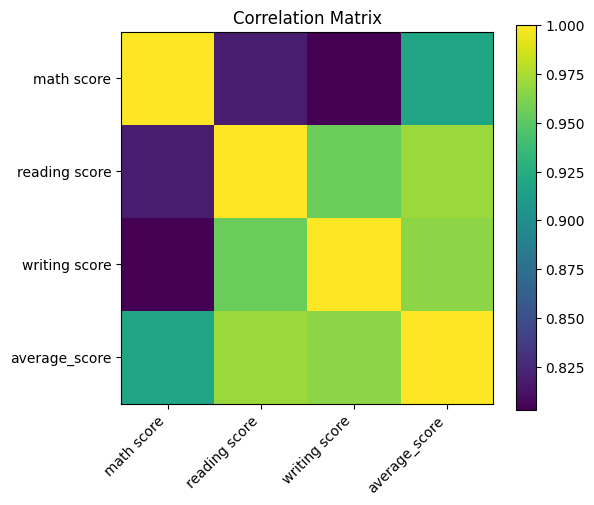

In [16]:
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.show()

### Вывод по корреляционной матрице

Корреляционная матрица показывает, насколько тесно связаны между собой числовые переменные — баллы по математике, чтению, письму и средний балл.

Выводы:

1. **Все экзаменационные баллы положительно связаны друг с другом.** Это означает, что студенты, которые хорошо справляются с одним экзаменом, как правило, показывают более высокие результаты и по другим предметам.
2. **Наиболее сильная связь обычно наблюдается между `reading score` и `writing score`.** Это логично, потому что оба экзамена связаны с языковыми и текстовыми навыками.
3. **`math score` также положительно связан с `reading score` и `writing score`, но эта связь может быть немного слабее**, так как математика требует частично других навыков.
4. **`average_score` сильно коррелирует со всеми тремя экзаменационными результатами**, потому что он рассчитывается как их среднее значение. Это техническая, а не самостоятельная поведенческая связь.
5. Для будущего моделирования важно учитывать, что `math score`, `reading score` и `writing score` нельзя использовать как признаки для предсказания `average_score`, иначе возникнет утечка данных: модель фактически получит компоненты целевой переменной.




## 11. Дополнительный анализ: прохождение подготовительного курса

Отдельно посмотрим, как результаты отличаются у студентов, которые прошли подготовительный курс, и у тех, кто его не проходил.

In [17]:
prep_stats = df.groupby("test preparation course")[score_columns].mean()
prep_stats

,math score,reading score,writing score,average_score
test preparation course,,,,
completed,69.695531,73.893855,74.418994,72.669460
none,64.077882,66.534268,64.504673,65.038941


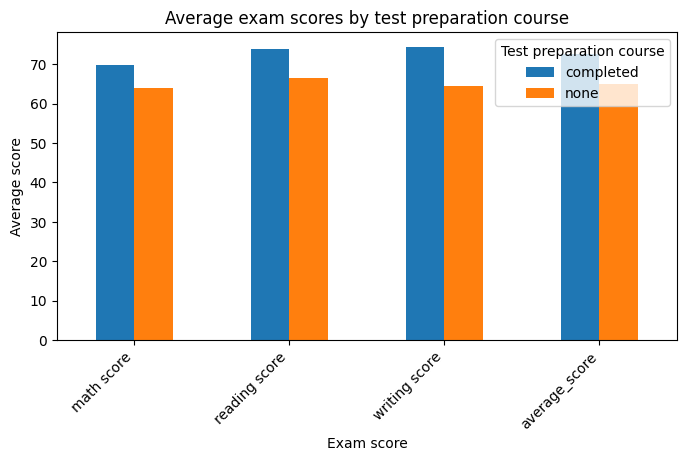

In [18]:
prep_stats.T.plot(kind="bar", figsize=(8, 4))

plt.title("Average exam scores by test preparation course")
plt.xlabel("Exam score")
plt.ylabel("Average score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Test preparation course")
plt.show()

### Вывод

Этот график позволяет оценить, связан ли подготовительный курс с более высокими результатами по отдельным экзаменам и по среднему баллу.

## 12. Постановка будущей ML-задачи

На основе проведенного EDA формулируем задачу машинного обучения.

Планируется решать задачу **регрессии**:

> по характеристикам студента предсказать его средний экзаменационный балл.

### Целевая переменная

`average_score`

### Признаки для будущей модели

В качестве признаков можно использовать:

- `gender`;
- `race/ethnicity`;
- `parental level of education`;
- `lunch`;
- `test preparation course`.




## 13. Финальные выводы по EDA

Проведенный разведочный анализ данных показал, что датасет имеет простую и понятную структуру: он содержит характеристики студентов и их результаты по трем экзаменам.

Основные выводы:

1. В данных представлены как категориальные характеристики студентов, так и числовые экзаменационные баллы.
2. На основе трех экзаменационных баллов была создана переменная `average_score`, отражающая общий уровень успеваемости.
3. Распределения экзаменационных баллов позволяют оценить, какие результаты встречаются чаще всего и есть ли крайние значения.
4. Средний балл отличается между различными группами студентов.
5. Потенциально важными факторами для будущей модели могут быть подготовительный курс, тип питания и уровень образования родителей.
6. Баллы по отдельным предметам положительно связаны между собой.
7. Проведенный EDA позволяет перейти к следующему этапу — построению модели регрессии для прогнозирования среднего экзаменационного балла.

### Ограничения анализа

Датасет содержит ограниченный набор признаков. В реальной жизни на успеваемость студентов также могут влиять мотивация, качество преподавания, посещаемость занятий, семейные условия и другие факторы, которых нет в данных.